# Series de Tiempo
## Monthly Mean Temp data set

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preparación

In [13]:
#Obtención de los df
data = pd.read_csv('./monthly-mean-temp.csv',
                    index_col = 'Month',
                    parse_dates = True)

# Separación de los data train/test
train_size = int(len(data) * 0.7)
train_data = data[0:train_size]
test_data = data[train_size:len(data)]

## Análisis exploratorio

In [14]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title="Reporte EDA", explorative=True)
profile.to_file("profiling_analisis/reporte3.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 338.00it/s]


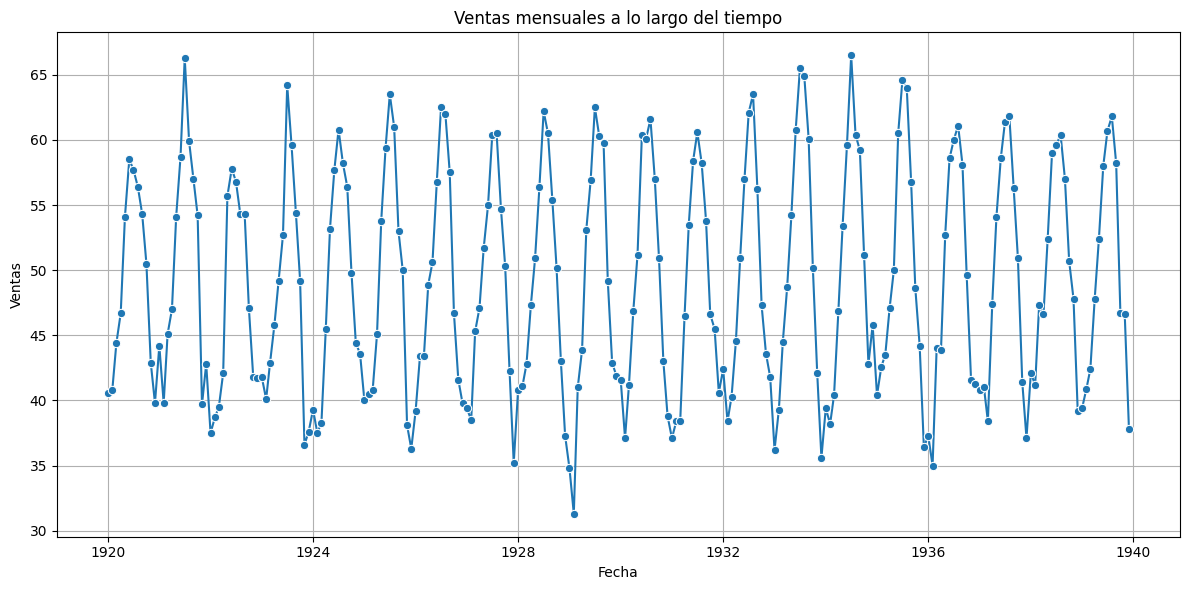

In [15]:
%matplotlib inline
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Month', y='Temperature', marker='o')
plt.title('Ventas mensuales a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.tight_layout()
plt.show()

Se observan ciclos anuales claros (patrón estacional).

Hay un aumento progresivo en las ventas con el tiempo lo que es indicio de una tendencia creciente.

Algunos picos muy pronunciados podrían indicar meses especiales o campañas.

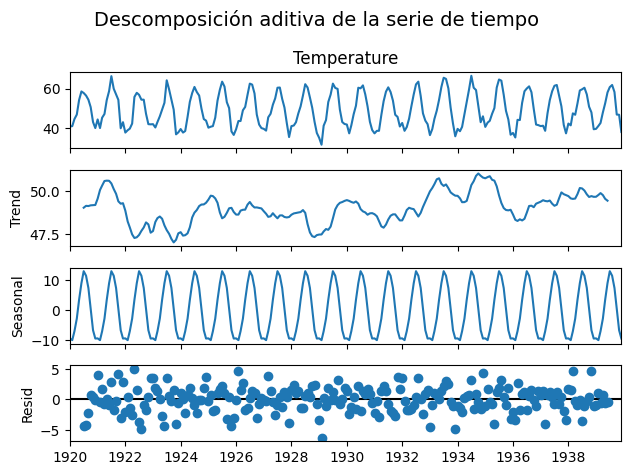

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición aditiva
result = seasonal_decompose(data['Temperature'], model='additive', period=12)

# Graficar la descomposición
result.plot()
plt.suptitle('Descomposición aditiva de la serie de tiempo', fontsize=14)
plt.tight_layout()
plt.show()

- Tendencia: Línea suave que muestra crecimiento continuo.
- Estacionalidad: Repetición de picos o valles según el mes.
- Ruido (residual): Variación aleatoria que no se explica por tendencia o estacionalidad.

## Algoritmos de Series de Tiempo

### Promedios Móviles

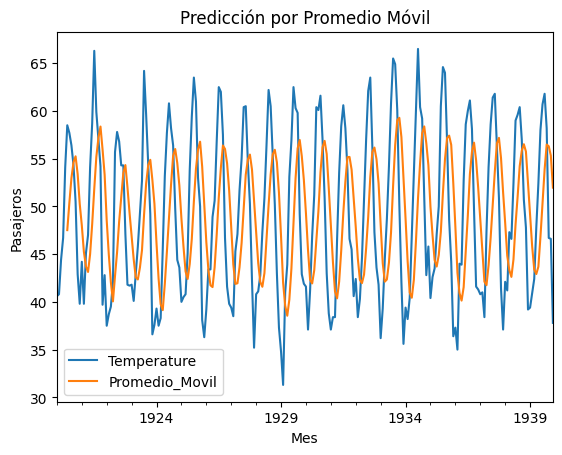

In [17]:
# Promedio Móvil
data['Promedio_Movil'] = data['Temperature'].rolling(window = 6).mean()

# Graficar los data y el Promedio Móvil
data[['Temperature', 'Promedio_Movil']].plot()
plt.title("Predicción por Promedio Móvil")
plt.xlabel("Mes")
plt.ylabel("Pasajeros")
plt.show()

El promedio móvil es un método puramente descriptivo y retrospectivo, no aprende patrones ni ajusta parámetros. Solo suaviza la serie calculando el promedio de los valores pasados en una ventana.
Por lo que, en general no tiene mucho sentido separar en train y test.

### Aislamiento exponencial

c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_Se

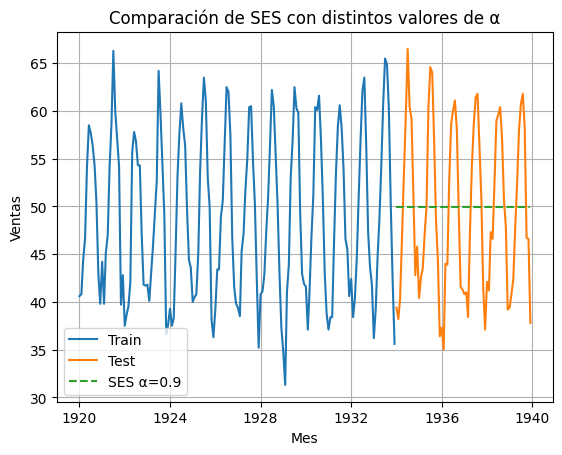

In [18]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

ses_results = []

for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    modelo = SimpleExpSmoothing(train_data['Temperature']).fit(smoothing_level=alpha, optimized=False)
    pred = modelo.forecast(len(test_data))
    
    rmse = np.sqrt(mean_squared_error(test_data['Temperature'], pred))
    mae = mean_absolute_error(test_data['Temperature'], pred)
    
    ses_results.append({'modelo': f'SES α={alpha}', 'RMSE': rmse, 'MAE': mae, 'predicciones': pred})

# Elección del mejor modelo
ses_df = pd.DataFrame(ses_results)
mejor_ses = ses_df.sort_values(by='RMSE').iloc[0]

# Graficar los datos reales
plt.plot(train_data.index, train_data['Temperature'], label='Train')
plt.plot(test_data.index, test_data['Temperature'], label='Test')

# Graficar la predicción
plt.plot(test_data.index, mejor_ses['predicciones'], label=f'SES α={alpha}', linestyle='--')

# Personalización de la gráfica
plt.title('Comparación de SES con distintos valores de α')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


### HOLT-WINTERS

c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_Se

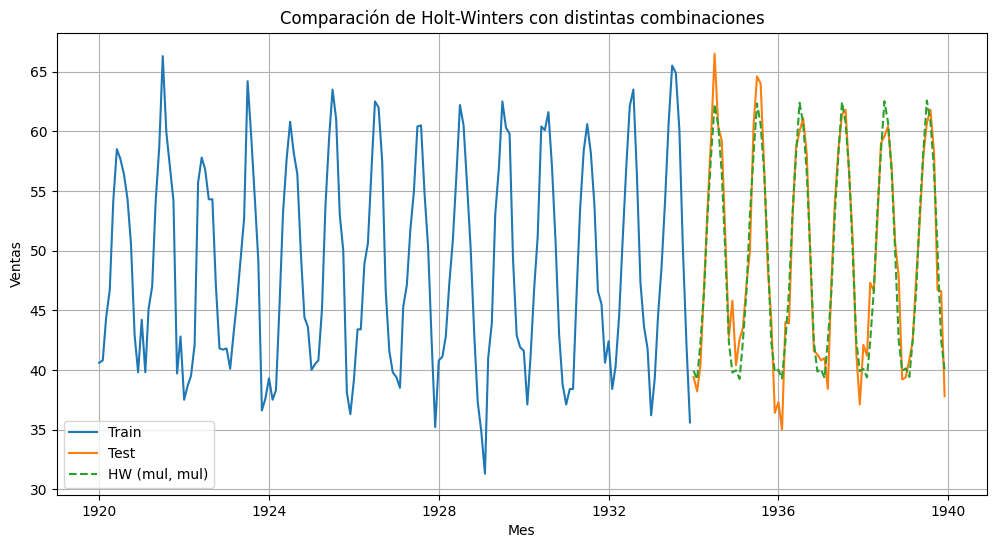

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_results = []
for trend in ['add', 'mul', None]:
    for seasonal in ['add', 'mul', None]:
        if trend == None and seasonal == None:
            continue
        try:
            modelo = ExponentialSmoothing(
                train_data['Temperature'],
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )
            fit = modelo.fit()
            pred = fit.forecast(len(test_data))

            rmse = np.sqrt(mean_squared_error(test_data['Temperature'], pred))
            mae = mean_absolute_error(test_data['Temperature'], pred)

            hw_results.append({
                'trend': trend,
                'seasonal': seasonal,
                'RMSE': rmse,
                'MAE': mae,
                'predicciones': pred
            })
        except:
            continue

hw_df = pd.DataFrame(hw_results)
best_hw = hw_df.sort_values(by='RMSE').iloc[0]

# Crear la figura
plt.figure(figsize=(12, 6))

# Graficar los datos reales
plt.plot(train_data.index, train_data['Temperature'], label='Train')
plt.plot(test_data.index, test_data['Temperature'], label='Test')

plt.plot(test_data.index, best_hw['predicciones'], label=f'HW ({best_hw['trend']}, {best_hw['seasonal']})', linestyle='--')

# Personalizar la gráfica
plt.title("Comparación de Holt-Winters con distintas combinaciones")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

### SARIMA

c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_SeriesDeTiempo\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Fabi\Documents\U\GitHub\Lab1_Se

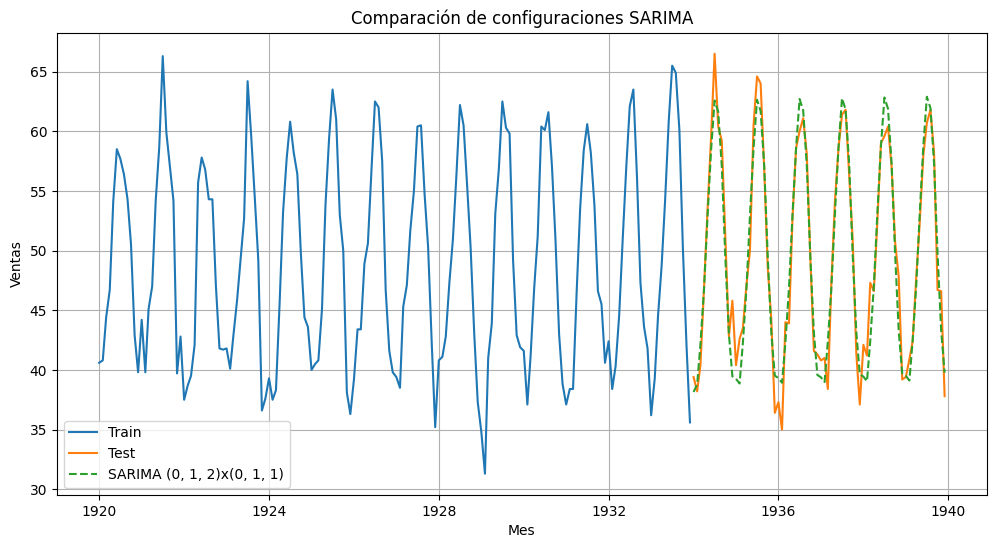

In [20]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definir los rangos
p = d = q = range(0, 3)
P = D = Q = range(0, 2)
seasonal_period = 12

# Combinaciones posibles de (p,d,q) y (P,D,Q,s)
param_combinations = list(itertools.product(p, d, q))
seasonal_combinations = list(itertools.product(P, D, Q))

# Para guardar resultados
sarima_results = []

for param in param_combinations:
    for seasonal in seasonal_combinations:
        try:
            model = SARIMAX(train_data['Temperature'],
                            order=param,
                            seasonal_order=(seasonal[0], seasonal[1], seasonal[2], seasonal_period),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            result = model.fit(disp=False)
            forecast = result.forecast(steps=len(test_data))

            rmse = np.sqrt(mean_squared_error(test_data['Temperature'], forecast))
            mae = mean_absolute_error(test_data['Temperature'], forecast)

            sarima_results.append({
                'params': param,
                'seasonal': seasonal,
                'RMSE': rmse,
                'MAE': mae,
                'predicciones': forecast
            })
        except:
            continue

# Convertir a DataFrame y obtener el mejor
sarima_df = pd.DataFrame(sarima_results)
best_sarima = sarima_df.sort_values(by='RMSE').iloc[0]

# Gráfico base con datos reales
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Temperature'], label='Train')
plt.plot(test_data.index, test_data['Temperature'], label='Test')

label = f"SARIMA {best_sarima['params']}x{best_sarima['seasonal']}"
plt.plot(test_data.index, best_sarima['predicciones'], linestyle='--', label=label)

# Personalización del gráfico
plt.title("Comparación de configuraciones SARIMA")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

### Prophet

12:35:00 - cmdstanpy - INFO - Chain [1] start processing
12:35:00 - cmdstanpy - INFO - Chain [1] done processing
12:35:00 - cmdstanpy - INFO - Chain [1] start processing
12:35:00 - cmdstanpy - INFO - Chain [1] done processing
12:35:01 - cmdstanpy - INFO - Chain [1] start processing
12:35:01 - cmdstanpy - INFO - Chain [1] done processing
12:35:01 - cmdstanpy - INFO - Chain [1] start processing
12:35:01 - cmdstanpy - INFO - Chain [1] done processing
12:35:01 - cmdstanpy - INFO - Chain [1] start processing
12:35:01 - cmdstanpy - INFO - Chain [1] done processing
12:35:01 - cmdstanpy - INFO - Chain [1] start processing
12:35:01 - cmdstanpy - INFO - Chain [1] done processing


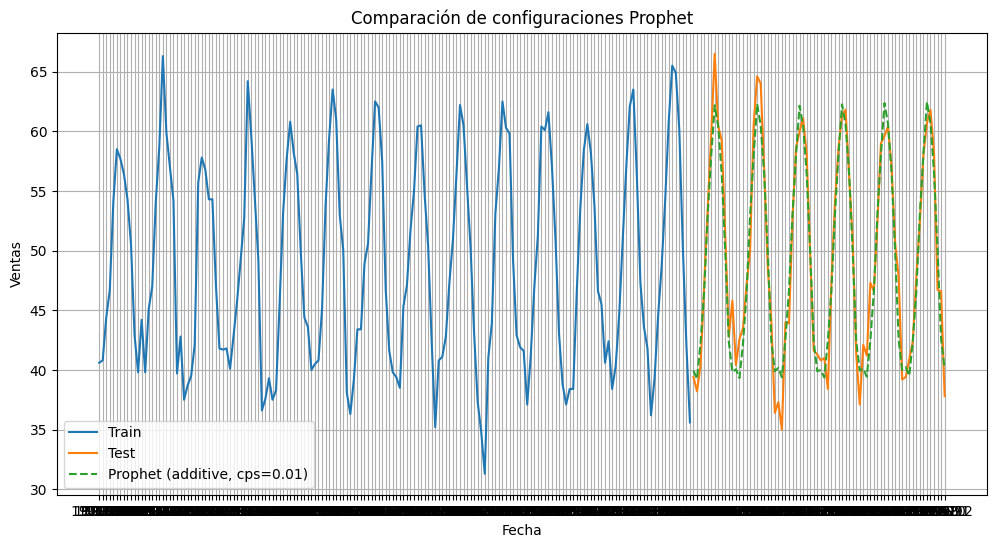

In [30]:
from prophet import Prophet

df = pd.read_csv('./monthly-mean-temp.csv')

# Cargar y preparar los datos
df['ds'] = df['Month']
df['y'] = df['Temperature'].astype(float)
df = df[['ds', 'y']]

# Separar en train y test (ej. 70/30)
train_size = int(len(df) * 0.7)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

prophet_results = []

for mode in ['additive', 'multiplicative']:
    for cps in [0.01, 0.1, 0.5]:
        try:
            model = Prophet(seasonality_mode=mode, changepoint_prior_scale=cps)
            model.fit(train_df)

            futuro = model.make_future_dataframe(periods=len(test_df), freq='MS')
            forecast = model.predict(futuro)

            pred = forecast.iloc[-len(test_df):]['yhat']
            rmse = np.sqrt(mean_squared_error(test_df['y'], pred))
            mae = mean_absolute_error(test_df['y'], pred)

            prophet_results.append({
                'mode': mode,
                'changepoint_prior_scale': cps,
                'RMSE': rmse,
                'MAE': mae,
                'predicciones': forecast,
                'modelo': model
            })
        except:
            continue

prophet_df = pd.DataFrame(prophet_results)
best_prophet = prophet_df.sort_values(by='mode').iloc[0]

# Graficar datos reales
plt.figure(figsize=(12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Train')
plt.plot(test_df['ds'], test_df['y'], label='Test')

label = f"Prophet ({best_prophet['mode']}, cps={best_prophet['changepoint_prior_scale']})"
plt.plot(test_df['ds'], best_prophet['predicciones'].iloc[-len(test_df):]['yhat'], linestyle='--', label=label)

# Personalización del gráfico
plt.title("Comparación de configuraciones Prophet")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

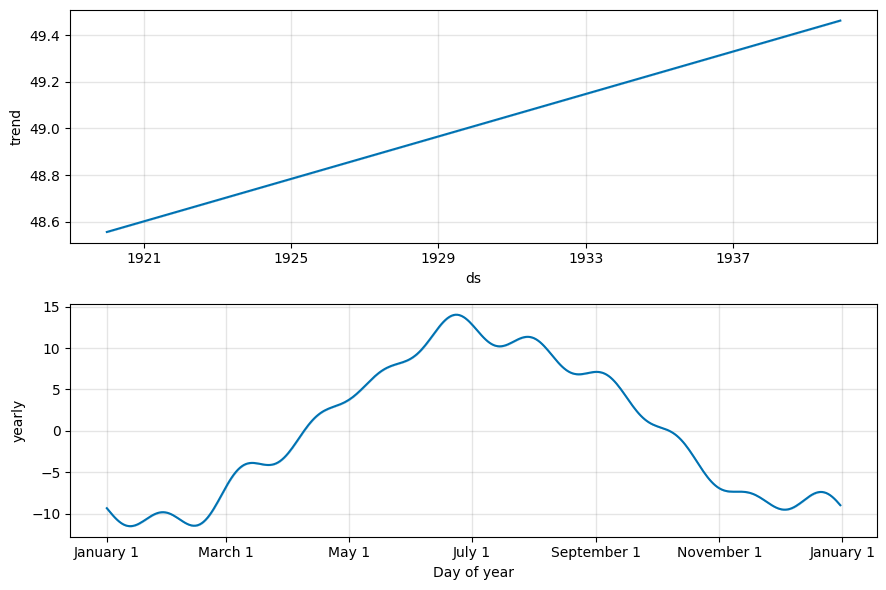

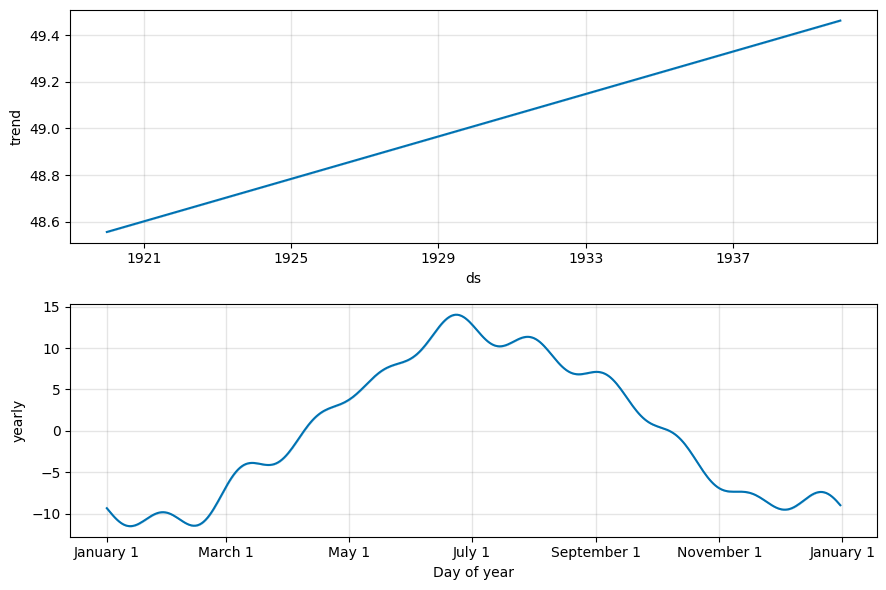

In [31]:
# Componentes de la serie
best_prophet['modelo'].plot_components(best_prophet['predicciones'])

## Comparación de algoritmos

In [32]:
mejores_modelos = [
    {'modelo': 'SES', 'RMSE': mejor_ses['RMSE'].min(), 'MAE': mejor_ses['MAE'].min()},
    {'modelo': 'Holt-Winters', 'RMSE': best_hw['RMSE'].min(), 'MAE': best_hw['MAE'].min()},
    {'modelo': 'SARIMA', 'RMSE': best_sarima['RMSE'].min(), 'MAE': best_sarima['MAE'].min()},
    {'modelo': 'Prophet', 'RMSE': best_prophet['RMSE'].min(), 'MAE': best_prophet['MAE'].min()}
]

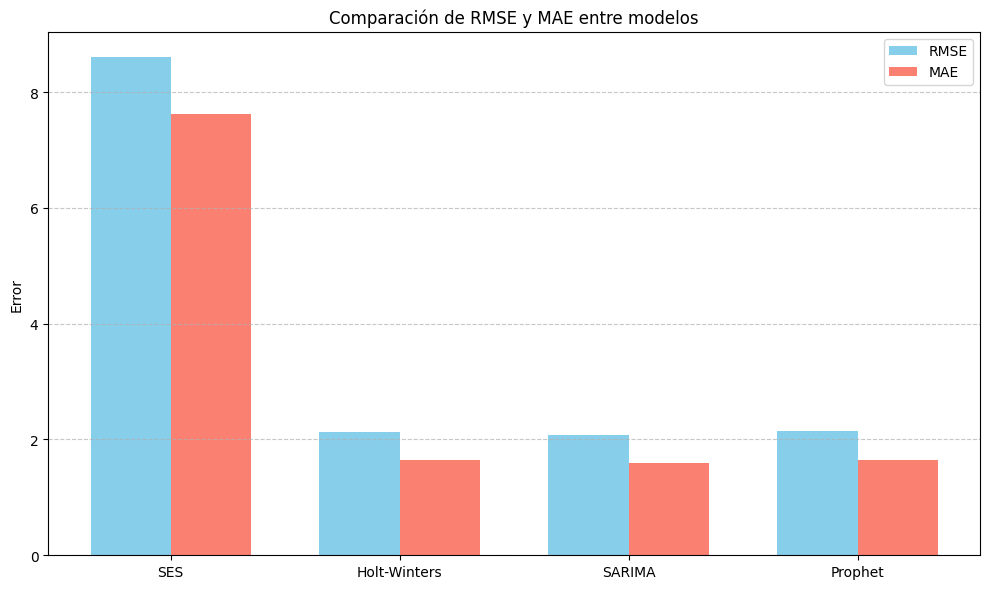

In [33]:
resultados_df = pd.DataFrame(mejores_modelos)

# Crear gráfico de barras agrupadas
bar_width = 0.35
x = range(len(resultados_df))

plt.figure(figsize=(10, 6))
plt.bar(x, resultados_df['RMSE'], width=bar_width, label='RMSE', color='skyblue')
plt.bar([i + bar_width for i in x], resultados_df['MAE'], width=bar_width, label='MAE', color='salmon')

# Etiquetas y detalles
plt.xticks([i + bar_width / 2 for i in x], resultados_df['modelo'])
plt.ylabel("Error")
plt.title("Comparación de RMSE y MAE entre modelos")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
